# Linear regression model for house price prediction


### Imports

In [116]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn import linear_model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [117]:
house_data = pd.read_csv('houses.csv')

In [118]:
house_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   bedrooms       999 non-null    float64
 1   bathrooms      999 non-null    float64
 2   sqft_living    999 non-null    float64
 3   sqft_lot       999 non-null    float64
 4   floors         999 non-null    float64
 5   waterfront     999 non-null    float64
 6   view           999 non-null    float64
 7   condition      999 non-null    float64
 8   grade          999 non-null    float64
 9   sqft_above     999 non-null    float64
 10  sqft_basement  999 non-null    float64
 11  yr_built       999 non-null    float64
 12  yr_renovated   999 non-null    float64
 13  zipcode        999 non-null    float64
 14  lat            999 non-null    float64
 15  long           999 non-null    float64
 16  sqft_living15  999 non-null    float64
 17  price          999 non-null    float64
dtypes: float6

In [119]:
house_data['bed_to_bath_ratio'] = house_data['bedrooms'] / (house_data['bathrooms'] + 0.1)
house_data['room_size'] = house_data['sqft_living'] / (house_data['bedrooms'] + house_data['bathrooms']+1)

house_data['waterfront_score'] = house_data['waterfront'] * house_data['view']

house_data['quality'] = house_data['condition'] * house_data['grade']

house_data['living_size'] = house_data['sqft_living'] / house_data['sqft_living15']

house_data['has_basement'] = (house_data['sqft_basement'] > 0).astype(int)

In [120]:
house_data.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,...,lat,long,sqft_living15,price,bed_to_bath_ratio,room_size,waterfront_score,quality,living_size,has_basement
0,3.0,1.00,1180.0,5650.0,1.0,0.0,0.0,3.0,7.0,1180.0,...,47.5112,-122.257,1340.0,22.19,2.727273,236.0,0.0,21.0,0.880597,0
1,3.0,2.25,2570.0,7242.0,2.0,0.0,0.0,3.0,7.0,2170.0,...,47.7210,-122.319,1690.0,53.80,1.276596,411.2,0.0,21.0,1.520710,1
2,2.0,1.00,770.0,10000.0,1.0,0.0,0.0,3.0,6.0,770.0,...,47.7379,-122.233,2720.0,18.00,1.818182,192.5,0.0,18.0,0.283088,0
3,4.0,3.00,1960.0,5000.0,1.0,0.0,0.0,5.0,7.0,1050.0,...,47.5208,-122.393,1360.0,60.40,1.290323,245.0,0.0,35.0,1.441176,1
4,3.0,2.00,1680.0,8080.0,1.0,0.0,0.0,3.0,8.0,1680.0,...,47.6168,-122.045,1800.0,51.00,1.428571,280.0,0.0,24.0,0.933333,0


In [121]:
house_data['house_age'] = 2026 - house_data['yr_built']
house_data['renovation_age'] = np.where(house_data['yr_renovated'] > 0, 2026 - house_data['yr_renovated'], 0)

house_data['age_condition'] = house_data['renovation_age'] / (house_data['quality'] + 1)

In [122]:
house_data.drop(columns = ['yr_built','yr_renovated'], inplace = True)

In [123]:
house_data.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,...,price,bed_to_bath_ratio,room_size,waterfront_score,quality,living_size,has_basement,house_age,renovation_age,age_condition
0,3.0,1.00,1180.0,5650.0,1.0,0.0,0.0,3.0,7.0,1180.0,...,22.19,2.727273,236.0,0.0,21.0,0.880597,0,71.0,0.0,0.000000
1,3.0,2.25,2570.0,7242.0,2.0,0.0,0.0,3.0,7.0,2170.0,...,53.80,1.276596,411.2,0.0,21.0,1.520710,1,75.0,35.0,1.590909
2,2.0,1.00,770.0,10000.0,1.0,0.0,0.0,3.0,6.0,770.0,...,18.00,1.818182,192.5,0.0,18.0,0.283088,0,93.0,0.0,0.000000
3,4.0,3.00,1960.0,5000.0,1.0,0.0,0.0,5.0,7.0,1050.0,...,60.40,1.290323,245.0,0.0,35.0,1.441176,1,61.0,0.0,0.000000
4,3.0,2.00,1680.0,8080.0,1.0,0.0,0.0,3.0,8.0,1680.0,...,51.00,1.428571,280.0,0.0,24.0,0.933333,0,39.0,0.0,0.000000


In [124]:
house_data_clean = house_data.dropna()

In [125]:
house_data_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 999 entries, 0 to 998
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   bedrooms           999 non-null    float64
 1   bathrooms          999 non-null    float64
 2   sqft_living        999 non-null    float64
 3   sqft_lot           999 non-null    float64
 4   floors             999 non-null    float64
 5   waterfront         999 non-null    float64
 6   view               999 non-null    float64
 7   condition          999 non-null    float64
 8   grade              999 non-null    float64
 9   sqft_above         999 non-null    float64
 10  sqft_basement      999 non-null    float64
 11  zipcode            999 non-null    float64
 12  lat                999 non-null    float64
 13  long               999 non-null    float64
 14  sqft_living15      999 non-null    float64
 15  price              999 non-null    float64
 16  bed_to_bath_ratio  999 non-null

In [126]:
house_data_clean.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,...,price,bed_to_bath_ratio,room_size,waterfront_score,quality,living_size,has_basement,house_age,renovation_age,age_condition
0,3.0,1.00,1180.0,5650.0,1.0,0.0,0.0,3.0,7.0,1180.0,...,22.19,2.727273,236.0,0.0,21.0,0.880597,0,71.0,0.0,0.000000
1,3.0,2.25,2570.0,7242.0,2.0,0.0,0.0,3.0,7.0,2170.0,...,53.80,1.276596,411.2,0.0,21.0,1.520710,1,75.0,35.0,1.590909
2,2.0,1.00,770.0,10000.0,1.0,0.0,0.0,3.0,6.0,770.0,...,18.00,1.818182,192.5,0.0,18.0,0.283088,0,93.0,0.0,0.000000
3,4.0,3.00,1960.0,5000.0,1.0,0.0,0.0,5.0,7.0,1050.0,...,60.40,1.290323,245.0,0.0,35.0,1.441176,1,61.0,0.0,0.000000
4,3.0,2.00,1680.0,8080.0,1.0,0.0,0.0,3.0,8.0,1680.0,...,51.00,1.428571,280.0,0.0,24.0,0.933333,0,39.0,0.0,0.000000


In [127]:
data = house_data_clean.dropna()

In [128]:
#ss = StandardScaler()

#house_data_scaled = ss.fit_transform(house_data_bloop)

In [129]:
#data = pd.DataFrame(house_data_scaled, columns = house_data_bloop.columns, index = house_data_bloop.index)

In [130]:
X = data.drop(columns = ['price'])
Y = data['price']

In [131]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.15, random_state=22)

In [132]:
train_temp = X_train.copy()
train_temp['price'] = Y_train
zip_price_map = train_temp.groupby('zipcode')['price'].mean().to_dict()

X_train['zip_mean_price'] = X_train['zipcode'].map(zip_price_map)
X_test['zip_mean_price'] = X_test['zipcode'].map(zip_price_map)

global_mean = Y_train.mean()
X_test['zip_mean_price'] = X_test['zip_mean_price'].fillna(global_mean)

In [133]:
model = linear_model.LinearRegression()

In [134]:
model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [135]:
Y_pred = model.predict(X_test)

In [136]:
print("coef",model.coef_)
print("intercept",model.intercept_)
print("r2_score",r2_score(Y_pred, Y_test))
print("mean_squared_error",mean_squared_error(Y_pred, Y_test))

coef [-5.62083196e+00  1.25624841e+01  1.45166850e-02  8.06700149e-06
  3.86053762e-01 -6.95068724e+01  6.84205724e+00 -1.24071641e+01
 -2.40911953e+00  7.50947080e-03  7.00721431e-03  3.90601444e-03
  1.59809807e+01 -9.81642620e+00 -8.49060132e-03  1.01631992e+01
  9.80610442e-03  3.80717374e+01  1.84610542e+00 -2.11363771e+01
 -1.67310411e+00  1.25364848e-01  2.33293530e+00 -5.31430231e+01
  5.55856159e-01]
intercept -2349.577381963298
r2_score 0.8343922721140657
mean_squared_error 174.8823618617479


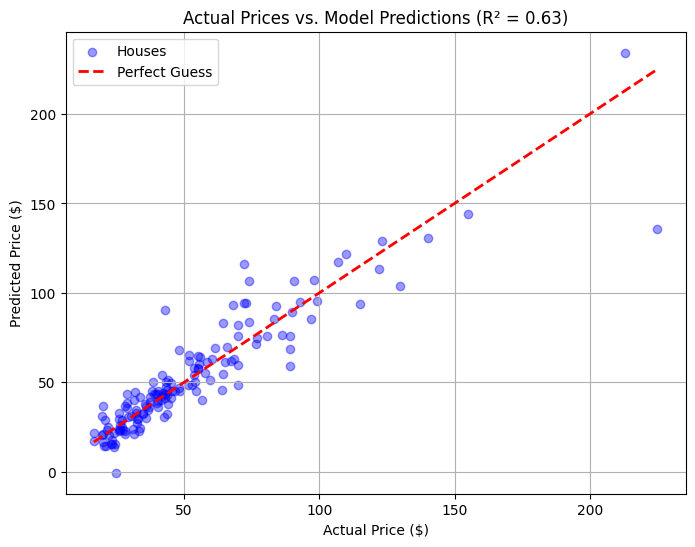

In [137]:
plt.figure(figsize=(8, 6))
plt.scatter(Y_test, model.predict(X_test), alpha=0.4, color='blue', label='Houses')

plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], color='red', linestyle='--', linewidth=2, label='Perfect Guess')

#label
plt.title('Actual Prices vs. Model Predictions (R² = 0.63)')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.legend()
plt.grid(True)
plt.show()

In [138]:
# Quick check: if this prints actual high numbers (like 1500 sqft), it didn't scale!
# If it scales, the max should be around 2 to 4.
print("X_train Max values:\n", X_train.max())

X_train Max values:
 bedrooms                  7.000000
bathrooms                 5.000000
sqft_living            6050.000000
sqft_lot             315374.000000
floors                    3.500000
waterfront                1.000000
view                      4.000000
condition                 5.000000
grade                    12.000000
sqft_above             6050.000000
sqft_basement          2060.000000
zipcode               98199.000000
lat                      47.777600
long                   -121.709000
sqft_living15          4550.000000
bed_to_bath_ratio         4.545455
room_size              3064.000000
waterfront_score          4.000000
quality                  50.000000
living_size               2.375000
has_basement              1.000000
house_age               126.000000
renovation_age           81.000000
age_condition             3.272727
zip_mean_price          122.934615
dtype: float64
